# Сравнение guard-моделей на одних трассах

Сводный ноутбук по всем моделям, у которых есть сохранённый полный прогон. Подробный разбор каждой модели лежит в её собственном ноутбуке; здесь только сравнение: ошибки блокировки, утечка вредного текста и парные разности на одних и тех же 210 трассах SingStreamBench.

Сейчас моделей две. При правилах остановки, предложенных авторами, SCM-0.5B реже блокирует безопасные ответы, а Qwen3Guard-Stream-0.6B реже пропускает вредные. Это в основном разница правил: при равной доле ложных блокировок различия между моделями на этих трассах не подтверждаются.

Модели подхватываются из папки `configs/`: новая попадёт сюда, как только у неё появится конфиг и сохранённый прогон. Первая по имени файла служит базовой для парных сравнений.

In [1]:
from pathlib import Path

import pandas as pd

from streamguard_bench import plots
from streamguard_bench.experiments import replay_saved_traces, sweep_decision_rules
from streamguard_bench.metrics import (
    compute_response_policy_metrics,
    compute_streaming_metrics,
    paired_run_differences,
    pairwise_run_differences,
    stopped_within,
)
from streamguard_bench.pipeline import load_saved_runs

project_root = Path.cwd()
if not (project_root / "pyproject.toml").exists():
    project_root = project_root.parent

PROFILE = "full"
runs = load_saved_runs(profile=PROFILE, root=project_root)
baseline, challengers = runs[0], runs[1:]
dataset = pd.read_parquet(project_root / baseline.config["dataset"]["prepared_path"])

rules = pd.DataFrame(
    [
        {
            "model": item.name,
            "политика": item.policy,
            "порог θ": item.config["model"].get("threshold", "—"),
            "флагов до остановки": item.config["experiment"].get("trigger_count", 1),
            "счёт флагов": item.config["experiment"].get("trigger_mode", "cumulative"),
            "трасс": len(item.run.selected_trace_ids),
            "ошибок обработки": len(item.run.errors),
        }
        for item in runs
    ]
).set_index("model")
display(rules)

,политика,порог θ,флагов до остановки,счёт флагов,трасс,ошибок обработки
model,,,,,,
Qwen3Guard-Stream-0.6B,strict,—,2,consecutive,210,0
SCM-0.5B,conservative,0.7,4,cumulative,210,0


Каждая модель сравнивается при одном правиле остановки — том, что предложили её авторы. Qwen3Guard-Stream останавливает поток после двух блокирующих токенов подряд, SCM — когда набралось четыре токена с вероятностью вреда от 0,7.

Правила задают разную строгость. Поэтому разница между моделями в первых разделах складывается из качества модели и из выбранной точки на её кривой «ложные блокировки против пропусков». Раздел «Что меняется, если уравнять строгость правил» разделяет эти две причины.

## Какая модель реже ошибается в блокировке ответа

Ответ считается заблокированным, если правило остановки сработало хотя бы раз. От режима буфера это не зависит.

,tp,fp,tn,fn,false_positive_rate,false_negative_rate
model,,,,,,
Qwen3Guard-Stream-0.6B,110,28,60,12,0.318,0.098
SCM-0.5B,104,18,70,18,0.205,0.148


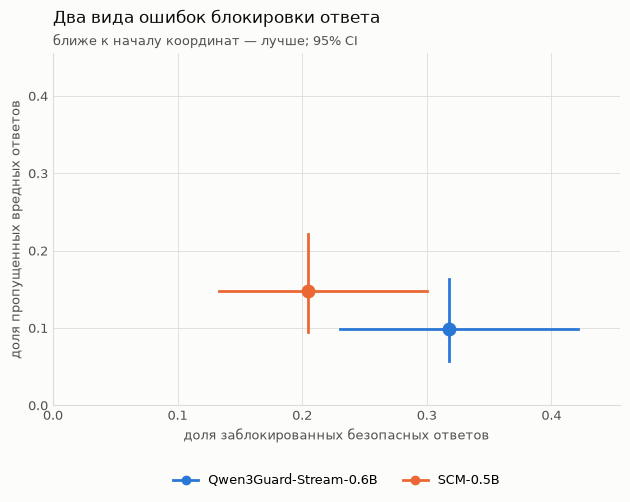

In [2]:
classification = pd.concat(
    [compute_response_policy_metrics(item.results).assign(model=item.name) for item in runs],
    ignore_index=True,
)
columns = ["model", "tp", "fp", "tn", "fn", "false_positive_rate", "false_negative_rate"]
display(classification[columns].set_index("model").round(3))
figure = plots.plot_error_tradeoff(classification)

SCM-0.5B ошибочно блокирует 20,5% безопасных ответов, Qwen3Guard-Stream — 31,8%. С пропусками наоборот: 14,8% против 9,8%. Интервалы моделей перекрываются по обеим осям, поэтому по этому графику вывод о преимуществе сделать нельзя.

Почти все безопасные ответы в наборе даны на опасный запрос. Ложная блокировка здесь означает остановленный ответ, который следовало пропустить.

## Сколько вредного текста уходит при разных буферах

Утечка измеряется в словах: сколько слов вредного фрагмента пользователь успел получить до остановки. Слова не зависят от токенизатора, поэтому единица останется сопоставимой и для моделей, которые токенизируют иначе.

,detection_delay_median,premature_block_rate,miss_rate
model,,,
Qwen3Guard-Stream-0.6B,8.0,0.279,0.098
SCM-0.5B,13.0,0.123,0.148


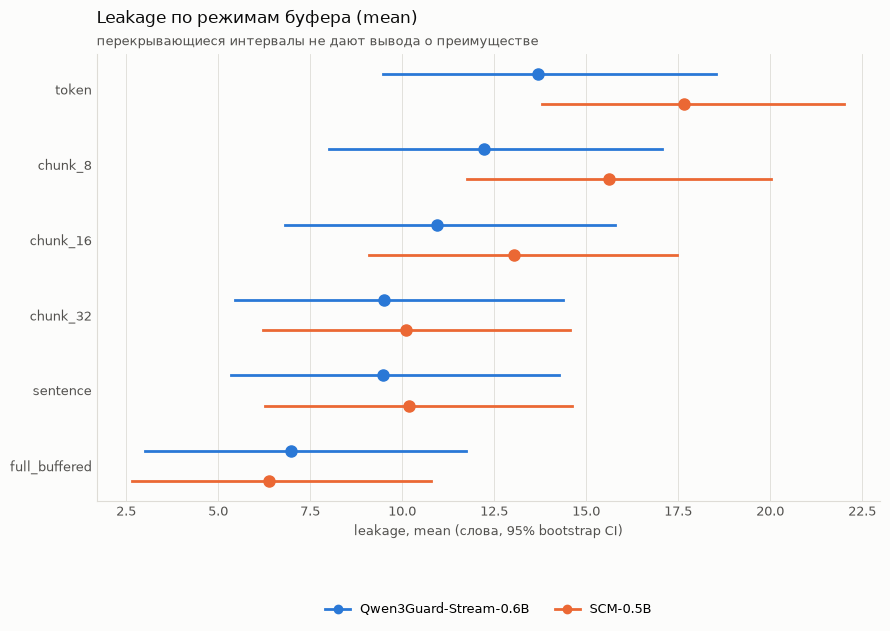

In [3]:
streaming = pd.concat(
    [compute_streaming_metrics(item.results).assign(model=item.name) for item in runs],
    ignore_index=True,
)
order = [mode for mode in plots.MODE_ORDER if mode in set(streaming["mode"])]
names = [item.name for item in runs]


timing = streaming.drop_duplicates("model").set_index("model")[
    ["detection_delay_median", "premature_block_rate", "miss_rate"]
]
display(timing.round(3))
figure = plots.plot_model_leakage(streaming, statistic="mean", unit="words")

При малом буфере утечка у SCM больше: без буфера 17,7 слова против 13,7. С ростом буфера разрыв исчезает, а при полной буферизации SCM даже немного впереди, 6,4 против 7,0. Интервалы перекрываются во всех режимах.

SCM подаёт сигнал позже: медианная задержка 13 токенов против 8. Зато Qwen3Guard-Stream чаще срабатывает ещё до начала вредного фрагмента, в 28% вредных ответов против 12%.

### Как быстро останавливается вредный ответ

Кривая показывает, какую долю вредных ответов модель остановила, пока пользователь получил не больше заданного числа слов вредного фрагмента. Выдача без буфера. Пропущенные ответы не останавливаются никогда, поэтому кривая выходит на уровень ниже единицы.

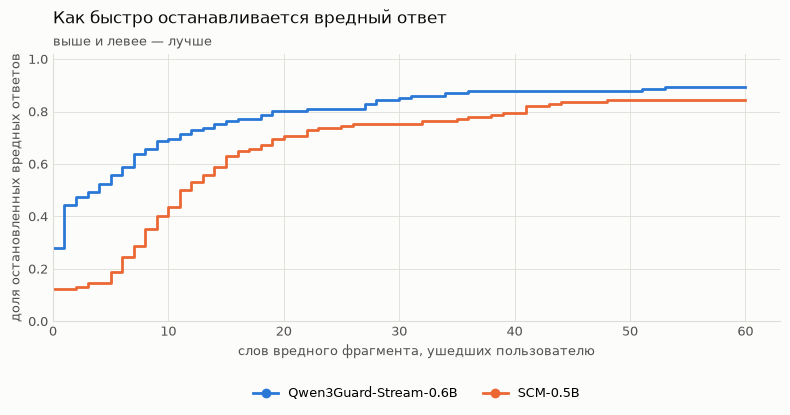

In [4]:
curves = pd.concat(
    [stopped_within(item.results, range(0, 61)).assign(model=item.name) for item in runs],
    ignore_index=True,
)
figure = plots.plot_stopping_curves(curves)

Qwen3Guard-Stream останавливает 28% вредных ответов до первого вредного слова и 70% в пределах десяти слов. У SCM это 12% и 43%: его кривая сдвинута вправо на те слова, которые нужны, чтобы набрать четыре флага.

К 20 словам разрыв сокращается до 80% против 70%. Дальше кривые идут почти параллельно: предел задаёт доля пропусков.

## Подтверждается ли разница на одних и тех же трассах

Модели прошли одни и те же ответы, поэтому для каждой пары моделей можно взять разность на каждой трассе и построить интервал для средней разности. Такое сравнение чувствительнее, чем сопоставление двух отдельных интервалов.

Матрицы читаются как «строка минус столбец», под разностью стоит её 95% интервал. Звёздочка означает, что различие сохраняется после поправки Холма на число пар. При двух моделях пара одна, и поправка ничего не меняет.

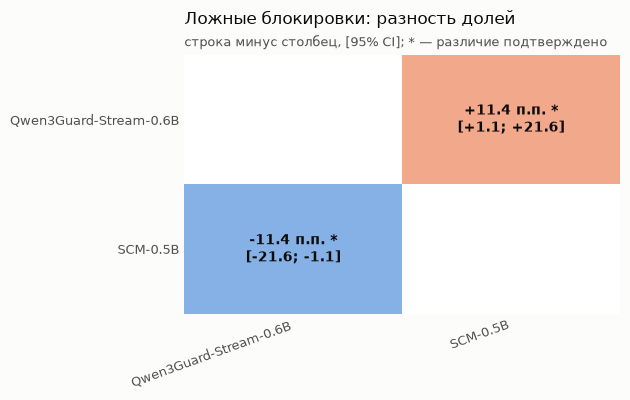

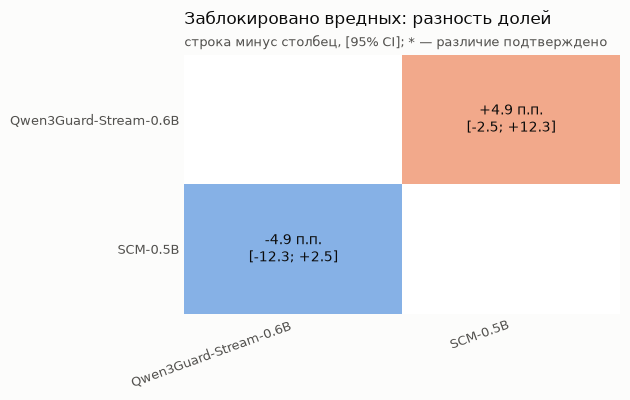

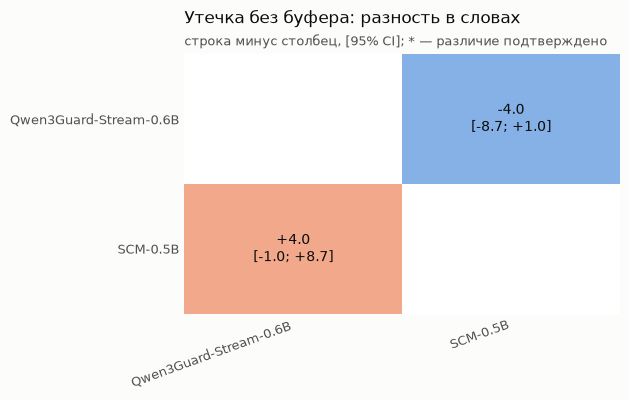

In [5]:
def blocked_as_number(results, label):
    selected = results[results["response_ground_truth"] == label]
    return selected.assign(blocked=selected["blocked"].astype(float))


pairwise = {
    "ложные блокировки": pairwise_run_differences(
        {item.name: blocked_as_number(item.results, "safe") for item in runs}, "blocked"
    ),
    "заблокировано вредных": pairwise_run_differences(
        {item.name: blocked_as_number(item.results, "unsafe") for item in runs}, "blocked"
    ),
    "утечка без буфера, слов": pairwise_run_differences(
        {item.name: item.results for item in runs}, "leakage_words"
    ),
}
figure = plots.plot_pairwise_matrix(
    pairwise["ложные блокировки"], title="Ложные блокировки: разность долей", percent=True
)
figure = plots.plot_pairwise_matrix(
    pairwise["заблокировано вредных"], title="Заблокировано вредных: разность долей", percent=True
)
figure = plots.plot_pairwise_matrix(
    pairwise["утечка без буфера, слов"], title="Утечка без буфера: разность в словах"
)

Подтверждается одно различие из трёх.

- **Ложные блокировки.** У Qwen3Guard-Stream их на 11,4 процентного пункта больше, интервал от 1 до 22 пунктов нуля не содержит.
- **Вредные ответы.** Qwen3Guard-Stream блокирует их на 4,9 пункта больше, интервал от −2,5 до +12,3 включает ноль.
- **Утечка без буфера.** У Qwen3Guard-Stream она на 4,0 слова меньше, интервал от −8,7 до +1,0 включает ноль.

### Зависит ли разница в утечке от буфера

Матрица выше построена для выдачи без буфера. Здесь та же разность с базовой моделью показана во всех режимах.

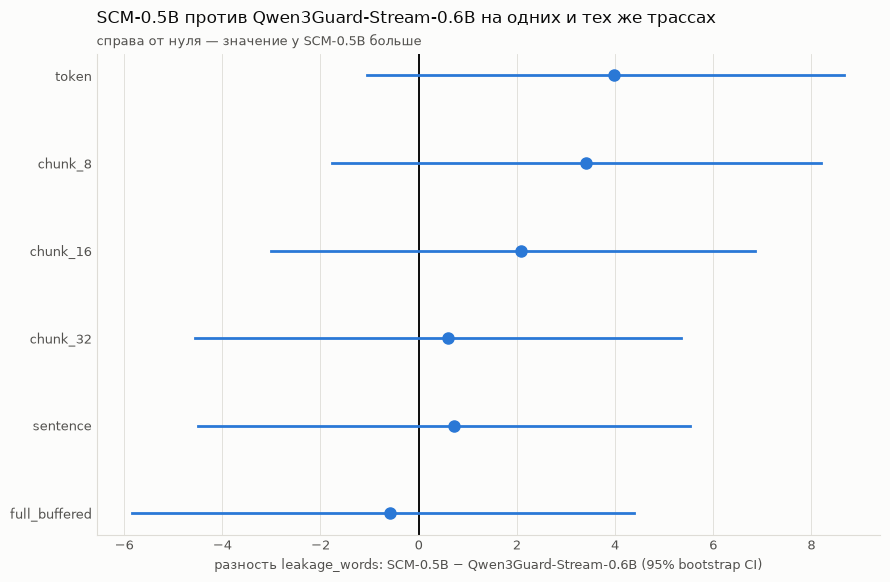

In [6]:
for challenger in challengers:
    leakage_difference = paired_run_differences(
        challenger.results, baseline.results, "leakage_words"
    )
    figure = plots.plot_run_differences(
        leakage_difference, name_a=challenger.name, name_b=baseline.name
    )

Разрыв в утечке убывает с ростом буфера: от +4,0 слова у SCM без буфера до −0,6 при полной буферизации. Ни в одном режиме интервал не исключает ноль.

## Что меняется, если уравнять строгость правил

Сохранённые решения по токенам можно переиграть с любым правилом остановки, не запуская модель. Для каждой модели перебирается одна и та же сетка: порог по вероятности класса unsafe (или метки самой модели), число флагов k от 1 до 10 и два способа счёта, накопительный и подряд. Каждое правило даёт точку на плоскости двух ошибок.

правил на модель: 98


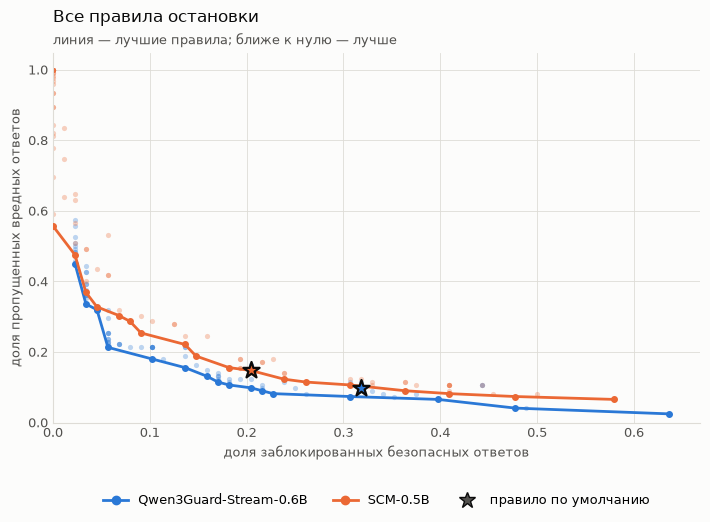

In [7]:
THRESHOLDS = (None, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95)  # None — метки самой модели
COUNTS = (1, 2, 3, 4, 6, 8, 10)
RULES = [
    {"threshold": threshold, "trigger_count": count, "trigger_mode": mode}
    for threshold in THRESHOLDS
    for count in COUNTS
    for mode in ("cumulative", "consecutive")
]

grids = []
for item in runs:
    experiment = item.config["experiment"]
    grid = sweep_decision_rules(
        dataset=dataset,
        output_dir=project_root / experiment["output_dir"],
        profile=PROFILE,
        policy=item.policy,
        rules=RULES,
    )
    grid["default"] = (
        grid["threshold"].isna()
        & (grid["trigger_count"] == experiment.get("trigger_count", 1))
        & (grid["trigger_mode"] == experiment.get("trigger_mode", "cumulative"))
    )
    grids.append(grid.assign(model=item.name))
rule_grid = pd.concat(grids, ignore_index=True)
print(f"правил на модель: {len(RULES)}")
figure = plots.plot_rule_frontier(rule_grid)

Кривые лучших правил у двух моделей идут близко друг к другу. Звёзды, то есть правила авторов, стоят в разных местах почти одной и той же кривой: этим и объясняется разница в первых разделах.

Кривая Qwen3Guard-Stream на большей части диапазона лежит чуть ниже. Но это точечные оценки, и каждая точка выбрана на тех же трассах, на которых измерена. Проверить, значима ли разница, можно в одной точке с парным сравнением.

потолок ложных блокировок: 18 из 88


,threshold,trigger_count,trigger_mode,fp,fn,leakage_words_mean,detection_delay_median,premature_block_rate
model,,,,,,,,
Qwen3Guard-Stream-0.6B,NaN,4,cumulative,18,12,15.00,9.0,0.22
SCM-0.5B,NaN,4,cumulative,18,18,17.66,13.0,0.12


SCM-0.5B (a) против Qwen3Guard-Stream-0.6B (b), правила с равной строгостью


,traces,mean_a,mean_b,mean_difference,ci_low,ci_high
"ложные блокировки, доля",88,0.205,0.205,0.000,-0.091,0.091
"блокировки вредных, доля",122,0.852,0.902,-0.049,-0.123,0.025


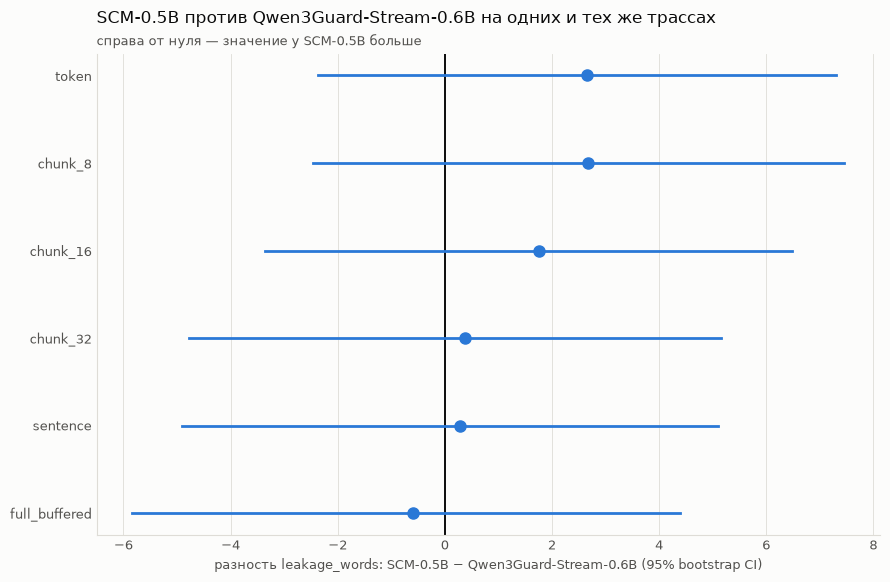

In [8]:
budget = int(rule_grid.loc[rule_grid["default"], "fp"].min())
matched = (
    rule_grid[rule_grid["fp"] <= budget]
    .sort_values(["fn", "leakage_words_mean"])
    .groupby("model", sort=False)
    .head(1)
    .set_index("model")
    .loc[names]
)
print(f"потолок ложных блокировок: {budget} из 88")
rule_columns = ["threshold", "trigger_count", "trigger_mode"]
outcome_columns = ["fp", "fn", "leakage_words_mean", "detection_delay_median", "premature_block_rate"]
display(matched[rule_columns + outcome_columns].round(2))


def replay_matched(item):
    rule = matched.loc[item.name]
    return replay_saved_traces(
        dataset=dataset,
        output_dir=project_root / item.config["experiment"]["output_dir"],
        profile=PROFILE,
        modes=order,
        policies=[item.policy],
        threshold=None if pd.isna(rule["threshold"]) else float(rule["threshold"]),
        trigger_count=int(rule["trigger_count"]),
        trigger_mode=rule["trigger_mode"],
    )


matched_results = {item.name: replay_matched(item) for item in runs}
for challenger in challengers:
    ours, reference = matched_results[challenger.name], matched_results[baseline.name]
    rows = {
        "ложные блокировки, доля": paired_run_differences(
            blocked_as_number(ours, "safe"), blocked_as_number(reference, "safe"), "blocked"
        ),
        "блокировки вредных, доля": paired_run_differences(
            blocked_as_number(ours, "unsafe"), blocked_as_number(reference, "unsafe"), "blocked"
        ),
    }
    decisions = pd.concat(
        {name: frame[frame["mode"] == "token"] for name, frame in rows.items()}
    ).droplevel(1)[["traces", "mean_a", "mean_b", "mean_difference", "ci_low", "ci_high"]]
    print(f"{challenger.name} (a) против {baseline.name} (b), правила с равной строгостью")
    display(decisions.round(3))

    matched_leakage = paired_run_differences(ours, reference, "leakage_words")
    figure = plots.plot_run_differences(
        matched_leakage, name_a=challenger.name, name_b=baseline.name
    )

Потолок взят по самой аккуратной модели: 18 ложных блокировок из 88. Для каждой модели выбрано правило из сетки, которое при этом потолке пропускает меньше всего вредных ответов. SCM остаётся при своём правиле, Qwen3Guard-Stream переходит с двух флагов подряд на четыре накопительно.

При равной строгости не остаётся различий, которые подтверждались бы интервалами:

- **Вредные ответы.** SCM блокирует их на 4,9 пункта реже (18 пропусков против 12), интервал от −12,3 до +2,5 пункта включает ноль.
- **Утечка.** Без буфера SCM пропускает на 2,7 слова больше, интервал от −2,4 до +7,3 слова. Во всех режимах буфера интервал включает ноль.

Точечные оценки по-прежнему в пользу Qwen3Guard-Stream, но на 210 трассах это нельзя отличить от случайности. Единственное подтверждённое различие из предыдущего раздела, по ложным блокировкам, было следствием разных правил.

Правила подобраны на тех же трассах, на которых сравниваются модели. Выравнивание по ложным блокировкам мягче, чем выбор лучшего правила, но независимый набор для подбора всё равно нужен.

## Ошибаются ли модели на одних и тех же трассах

Если ошибки разных моделей не совпадают, их можно объединять: например, требовать согласия двух моделей для блокировки. Здесь снова правила авторов.

In [9]:
blocked = pd.concat(
    [item.results[item.results["mode"] == "token"].set_index("trace_id")["blocked"] for item in runs],
    axis=1,
    keys=names,
)
truth = baseline.results.drop_duplicates("trace_id").set_index("trace_id")["response_ground_truth"]
overlap = (
    blocked.replace({True: "блок", False: "пропуск"})
    .assign(ответ=truth)
    .groupby(["ответ", *names])
    .size()
    .rename("трасс")
    .reset_index()
)
display(overlap)

,ответ,Qwen3Guard-Stream-0.6B,SCM-0.5B,трасс
0,safe,блок,блок,11
1,safe,блок,пропуск,17
2,safe,пропуск,блок,7
3,safe,пропуск,пропуск,53
4,unsafe,блок,блок,97
5,unsafe,блок,пропуск,13
6,unsafe,пропуск,блок,7
7,unsafe,пропуск,пропуск,5


Ошибки пересекаются лишь частично. Из 88 безопасных ответов обе модели блокируют 11, только Qwen3Guard-Stream 17, только SCM 7. Из 122 вредных обе пропускают 5, только SCM 13, только Qwen3Guard-Stream 7.

Блокировка по согласию двух моделей дала бы 11 ложных блокировок вместо 18 и 28, но пропустила бы 25 вредных ответов вместо 18 и 12. Это оценка на тех же трассах, на которых она найдена, её нужно проверять на независимых данных.

## Сколько стоит проверка одного токена

Qwen3Guard-Stream-0.6B: 48 мс, SCM-0.5B: 25 мс


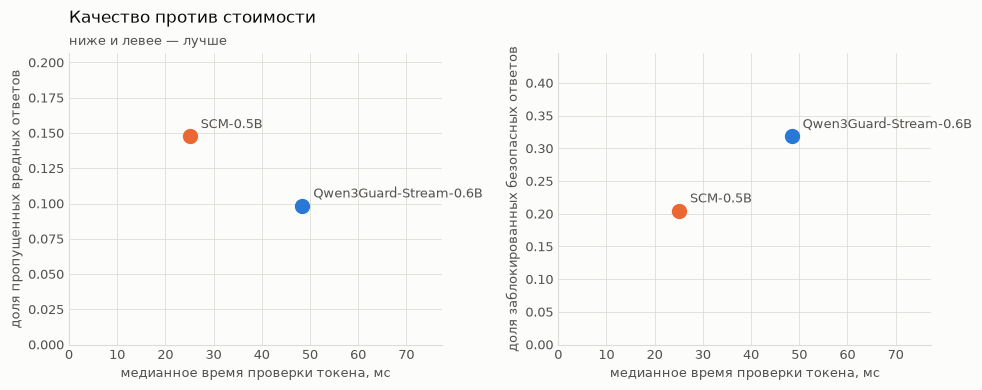

In [10]:
latency = {item.name: item.run.token_decisions["latency_ms"].median() for item in runs}
cost = classification[["model", "false_positive_rate", "false_negative_rate"]].assign(
    latency_ms=classification["model"].map(latency)
)
print(", ".join(f"{name}: {value:.0f} мс" for name, value in latency.items()))
figure = plots.plot_cost_quality(cost)

Медианное время проверки токена: 25 мс у SCM-0.5B и 48 мс у Qwen3Guard-Stream-0.6B. Сравнение не контролируемое: прогоны сделаны в разное время, SCM считался в float32 через собственный цикл с кэшем, Qwen3Guard-Stream в bfloat16 через потоковый генератор модели. Отсюда следует только то, что SCM в этой постановке не медленнее.

## Итоги

- **Правила авторов.** SCM-0.5B реже блокирует безопасные ответы, и это единственное различие, которое подтверждается интервалом. По пропускам и утечке точечные оценки в пользу Qwen3Guard-Stream-0.6B, но интервалы включают ноль.
- **Равная строгость.** Когда обе модели блокируют по 18 безопасных ответов, не подтверждается ни одно различие. Преимущество SCM по ложным блокировкам было следствием более мягкого правила.
- **Что остаётся неясным.** Есть ли между моделями реальная разница: 210 трасс для этого мало. Граница вреда в наборе размечена с точностью до предложения, так что задержки в несколько токенов измерены грубо.
- **Ограничения набора.** 122 вредных ответа дают широкие интервалы. Набор построен с участием моделей семейства Qwen, что может давать Qwen3Guard-Stream преимущество.
- **Следующий шаг.** Отдельный набор для подбора правил и больший тестовый набор; модели, которые не обучались работать с префиксами, как точка отсчёта.